<a href="https://colab.research.google.com/github/Naveen-gale/deep_learning/blob/main/deep_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

In [13]:
from tensorflow.keras.datasets import mnist

In [14]:
import numpy as np

(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [15]:
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [24]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [30]:
# Reloading data to ensure X_test and y_test dimensions match
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize the images
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f'Corrected X_test shape: {X_test.shape}')
print(f'Corrected y_test shape: {y_test.shape}')

Corrected X_test shape: (10000, 28, 28)
Corrected y_test shape: (10000,)


In [31]:
perseptron = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(10, activation='softmax')
])

In [32]:
perseptron.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [33]:
hestory_per= perseptron.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8655 - loss: 0.5158 - val_accuracy: 0.9103 - val_loss: 0.3201
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9117 - loss: 0.3182 - val_accuracy: 0.9197 - val_loss: 0.2868
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9175 - loss: 0.2935 - val_accuracy: 0.9219 - val_loss: 0.2777
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9215 - loss: 0.2819 - val_accuracy: 0.9273 - val_loss: 0.2686
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9231 - loss: 0.2735 - val_accuracy: 0.9249 - val_loss: 0.2702
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9250 - loss: 0.2683 - val_accuracy: 0.9267 - val_loss: 0.2648
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9261 - loss: 0.2640 - val_accuracy: 0.9288 - val_loss: 0.2645
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9273 - loss: 0.2608 - 

In [34]:
loss, accuracy = perseptron.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9258 - loss: 0.2716
Accuracy: 0.9258000254631042


In [40]:
from re import VERBOSE
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax'),

])

In [41]:
ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [42]:
ann.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9204 - loss: 0.2741 - val_accuracy: 0.9566 - val_loss: 0.1476
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9654 - loss: 0.1141 - val_accuracy: 0.9660 - val_loss: 0.1088
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9758 - loss: 0.0788 - val_accuracy: 0.9692 - val_loss: 0.0991
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9818 - loss: 0.0586 - val_accuracy: 0.9706 - val_loss: 0.1022
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9854 - loss: 0.0451 - val_accuracy: 0.9749 - val_loss: 0.0865


In [43]:
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')

])

In [44]:
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
hestory_cnn = cnn.fit(X_train.reshape(-1,28,28,1), y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.9460 - loss: 0.1713 - val_accuracy: 0.9762 - val_loss: 0.0812
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9846 - loss: 0.0518 - val_accuracy: 0.9840 - val_loss: 0.0550
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9889 - loss: 0.0342 - val_accuracy: 0.9863 - val_loss: 0.0465
Epoch 4/5
1436/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9911 - loss: 0.0260

In [46]:
loss , accuracy = cnn.evaluate(X_test.reshape(-1,28,28,1), y_test)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9883 - loss: 0.0386
Accuracy: 0.9883000254631042


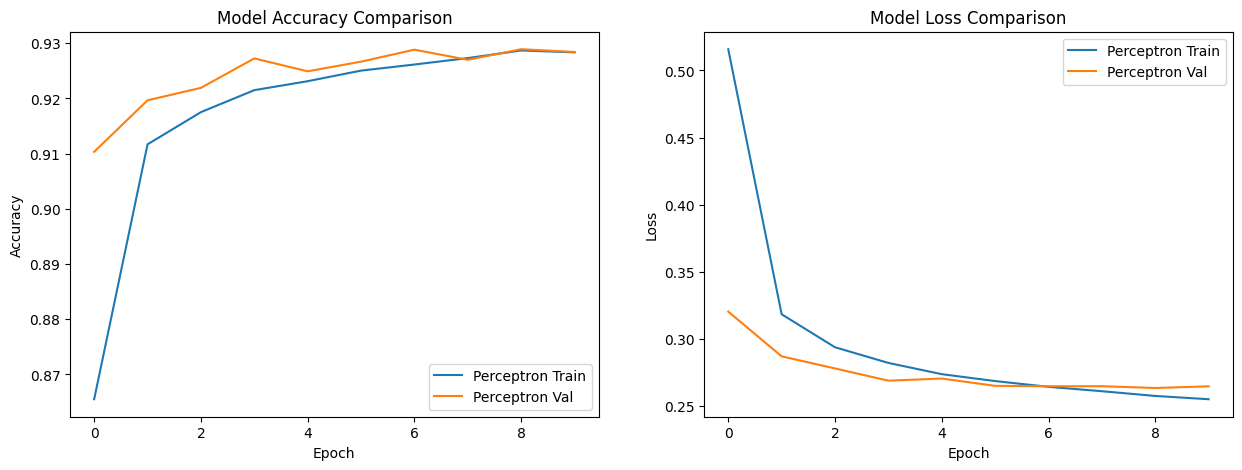

In [47]:
import matplotlib.pyplot as plt

# Note: Assuming ann.fit history was not explicitly saved to a variable in previous cells,
# but we have 'hestory_per' and 'hestory_cnn'.
# If you ran 'ann.fit' without assigning it, we will plot what we have.

plt.figure(figsize=(15, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(hestory_per.history['accuracy'], label='Perceptron Train')
plt.plot(hestory_per.history['val_accuracy'], label='Perceptron Val')
if 'hestory_cnn' in locals():
    plt.plot(hestory_cnn.history['accuracy'], label='CNN Train')
    plt.plot(hestory_cnn.history['val_accuracy'], label='CNN Val')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(hestory_per.history['loss'], label='Perceptron Train')
plt.plot(hestory_per.history['val_loss'], label='Perceptron Val')
if 'hestory_cnn' in locals():
    plt.plot(hestory_cnn.history['loss'], label='CNN Train')
    plt.plot(hestory_cnn.history['val_loss'], label='CNN Val')
plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


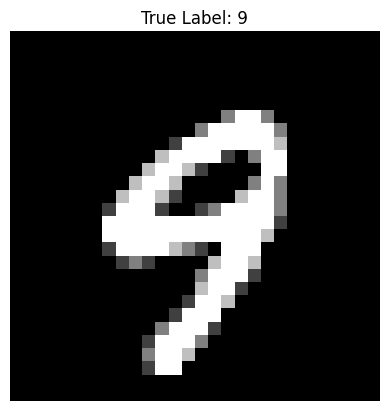

Perceptron Prediction: 9
ANN Prediction: 9
CNN Prediction: 9


In [56]:
import numpy as np

# Pick a random image from the test set
idx = np.random.randint(0, len(X_test))
test_image = X_test[idx]
true_label = y_test[idx]

# Prepare input for each model
# Perceptron & ANN expect (1, 28, 28)
# CNN expects (1, 28, 28, 1)
img_ann = test_image.reshape(1, 28, 28)
img_cnn = test_image.reshape(1, 28, 28, 1)

# Predictions
pred_per = np.argmax(perseptron.predict(img_ann), axis=1)[0]
pred_ann = np.argmax(ann.predict(img_ann), axis=1)[0]
pred_cnn = np.argmax(cnn.predict(img_cnn), axis=1)[0]

# Visualization
plt.imshow(test_image, cmap='gray')
plt.title(f"True Label: {true_label}")
plt.axis('off')
plt.show()

print(f"Perceptron Prediction: {pred_per}")
print(f"ANN Prediction: {pred_ann}")
print(f"CNN Prediction: {pred_cnn}")